# Effect sizes of pairwise invariance violations (original scales)

For every (scale × sample-pair) where the **full original item set** failed to reach and pass scalar invariance, this notebook quantifies how much the non-invariance distorts observed scores, using `hitop_cfa.dif_effect_sizes` (metric-model decomposition: uniform severity shift α via GLS projection; per-item non-uniform DIF dᵢ = ν̂ᵢ − λᵢα̂; signed item bias, dMACS, and net/gross sum-score bias, integrated over the focal group's latent distribution) — **with 95% CIs** simulated from the fit's robust parameter covariance.

Covers the HiTOP scales on all three sample pairs (val_gp, val_en, gp_en) and the PHQ/GAD/BAARS scales on gp_en plus the four wave comparisons. Fit-based only (no permutations). Outputs: `data/effect_sizes/`.

Caveat: where configural invariance already failed, the metric model is an approximation — treat those rows as order-of-magnitude quantifications (the `failed_at` column records each violation's level).

In [1]:
import os
for _var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(_var, "1")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hitop_cfa import dif_effect_sizes
from hitop_cfa.scales import ORIG_ITEMS, OTHER_SCALES

dat_dir = Path('../data')
fin_dir = dat_dir / 'finaldata'
out_dir = dat_dir / 'effect_sizes'
out_dir.mkdir(exist_ok=True)
temp_path = out_dir / 'es_temp.csv'
FORMULAS = {**ORIG_ITEMS, **OTHER_SCALES}
def items_of(scale):
    return FORMULAS[scale].split('=~', 1)[1].strip().split(' + ')

In [2]:
# pair datasets. grid1st for the sample pairs (concat orders match the
# pipelines); gridall wave frames for the wave comparisons
data_val = pd.read_csv(fin_dir / 'dat_val.csv')
data_gp = pd.read_csv(fin_dir / 'dat_gp_grid1st_full.csv')
data_en = pd.read_csv(fin_dir / 'dat_en_grid1st_full.csv')
gp_all = pd.read_csv(fin_dir / 'dat_gp_gridall_full.csv')
en_all = pd.read_csv(fin_dir / 'dat_en_gridall_full.csv')

_other_items = [i for f in OTHER_SCALES.values()
                for i in f.split('=~', 1)[1].strip().split(' + ')]

def _wave_frame(df, wave, label):
    if wave == 1:
        out = df[_other_items].copy()
    else:
        out = df[[f'{i}_recontact' for i in _other_items]].copy()
        out.columns = _other_items
    out['whichdata'] = label
    return out

PAIR_DATA = {
    'val_gp': pd.concat([data_val, data_gp]),
    'val_en': pd.concat([data_val, data_en]),
    'gp_en': pd.concat([data_gp, data_en]),
    'gp1_gp2': pd.concat([_wave_frame(gp_all, 1, 'gp_t1'), _wave_frame(gp_all, 2, 'gp_t2')]),
    'en1_en2': pd.concat([_wave_frame(en_all, 1, 'en_t1'), _wave_frame(en_all, 2, 'en_t2')]),
    'gp1_en2': pd.concat([_wave_frame(gp_all, 1, 'gp_t1'), _wave_frame(en_all, 2, 'en_t2')]),
    'gp2_en1': pd.concat([_wave_frame(gp_all, 2, 'gp_t2'), _wave_frame(en_all, 1, 'en_t1')]),
}

## Collect the violations

A (scale, pair) counts as a violation when the recorded baseline shows the full item set not reaching+passing scalar (`pscalar` NaN or < .05); `failed_at` = the first failing level (configural counts as passed when the ladder continued via the secondary criteria).

In [3]:
LEVELS = ['pconfig', 'pthresholds', 'pmetric', 'pscalar']
LEVEL_NAMES = ['configural', 'thresholds', 'metric', 'scalar']

def failed_at(row):
    cfg_ok = (pd.notna(row.pconfig) and row.pconfig >= 0.05) or pd.notna(row.pthresholds)
    if not cfg_ok:
        return 'configural'
    for col, name in zip(LEVELS[1:], LEVEL_NAMES[1:]):
        p = getattr(row, col)
        if pd.isna(p) or p < 0.05:
            return name
    return None  # passed scalar

SOURCES = [
    (dat_dir / 'cfa' / 'orig_cfa_res.csv',
     {'V_GP': 'val_gp', 'V_EN': 'val_en', 'GP_EN': 'gp_en'}),
    (dat_dir / 'cfa_other_gp_en' / 'orig_cfa_res.csv', {'GP_EN': 'gp_en'}),
    (dat_dir / 'cfa_other_gp1_gp2' / 'orig_cfa_res.csv', {'GP1_GP2': 'gp1_gp2'}),
    (dat_dir / 'cfa_other_en1_en2' / 'orig_cfa_res.csv', {'EN1_EN2': 'en1_en2'}),
    (dat_dir / 'cfa_other_gp1_en2' / 'orig_cfa_res.csv', {'GP1_EN2': 'gp1_en2'}),
    (dat_dir / 'cfa_other_gp2_en1' / 'orig_cfa_res.csv', {'GP2_EN1': 'gp2_en1'}),
]

violations = []
for path, pairmap in SOURCES:
    if not path.exists():
        print(f'[skip] {path} not found')
        continue
    df = pd.read_csv(path)
    for r in df.itertuples():
        if r.pair not in pairmap:
            continue
        level = failed_at(r)
        if level is not None:
            violations.append(dict(scale=r.scale, pair=pairmap[r.pair],
                                   failed_at=level, source=str(path.parent.name)))
violations = pd.DataFrame(violations).drop_duplicates(subset=['scale', 'pair'])
print(f'{len(violations)} pairwise violations of original scales:')
print(violations.groupby(['pair', 'failed_at']).size().unstack(fill_value=0))
violations

49 pairwise violations of original scales:
failed_at  configural  metric  scalar  thresholds
pair                                             
en1_en2             1       0       0           0
gp1_en2             3       1       0           1
gp1_gp2             1       0       0           0
gp2_en1             4       0       0           0
gp_en               4       1       4           3
val_en              2       4       6           1
val_gp              5       3       3           2


,scale,pair,failed_at,source
0,anhedonic_depression,val_gp,configural,cfa
1,anhedonic_depression,val_en,metric,cfa
2,anhedonic_depression,gp_en,thresholds,cfa
3,anxious_worry,val_gp,thresholds,cfa
4,anxious_worry,val_en,metric,cfa
5,anxious_worry,gp_en,metric,cfa
6,appetite_gain,val_gp,metric,cfa
7,appetite_gain,val_en,scalar,cfa
8,appetite_gain,gp_en,scalar,cfa
9,appetite_loss,val_gp,thresholds,cfa


## Compute effect sizes (with 95% CIs) for every violation

In [4]:
per_item_all, summary_all = [], []
for v in violations.itertuples():
    print(f'--- {v.scale} x {v.pair} (failed at {v.failed_at}) ---', flush=True)
    try:
        per_item, s = dif_effect_sizes(v.scale, items_of(v.scale),
                                       PAIR_DATA[v.pair], temp_path)
    except Exception as exc:
        print(f'    ERROR: {exc!r}')
        summary_all.append(dict(scale=v.scale, pair=v.pair,
                                failed_at=v.failed_at, error=repr(exc)))
        continue
    if per_item is None:
        print('    metric model did not converge')
        summary_all.append(dict(scale=v.scale, pair=v.pair,
                                failed_at=v.failed_at, error='nonconverged'))
        continue
    per_item.insert(0, 'pair', v.pair)
    per_item.insert(0, 'scale', v.scale)
    per_item_all.append(per_item)
    summary_all.append(dict(
        scale=v.scale, pair=v.pair, failed_at=v.failed_at,
        n_items=len(per_item), scale_max=s['scale_max_points'],
        alpha=round(s['alpha'], 3),
        alpha_lo=round(s['alpha_ci'][0], 3), alpha_hi=round(s['alpha_ci'][1], 3),
        real_gap_pts=round(s['real_gap_points'], 2),
        net_bias_pts=round(s['net_sum_bias_points'], 2),
        net_lo=round(s['net_ci'][0], 2), net_hi=round(s['net_ci'][1], 2),
        gross_bias_pts=round(s['gross_abs_bias_points'], 2),
        gross_lo=round(s['gross_ci'][0], 2), gross_hi=round(s['gross_ci'][1], 2),
        max_dMACS=round(per_item.dMACS.max(), 3),
        max_dMACS_item=per_item.loc[per_item.dMACS.idxmax(), 'item'],
        error=None))

per_item_all = pd.concat(per_item_all, ignore_index=True)
summary = pd.DataFrame(summary_all)
per_item_all.to_csv(out_dir / 'gp_pairwise_dif_per_item.csv', index=False)
summary.to_csv(out_dir / 'pairwise_dif_summary.csv', index=False)
print(f'\nsaved {len(per_item_all)} item rows / {len(summary)} scale-pair summaries to {out_dir}')

--- anhedonic_depression x val_gp (failed at configural) ---


--- anhedonic_depression x val_en (failed at metric) ---


--- anhedonic_depression x gp_en (failed at thresholds) ---


--- anxious_worry x val_gp (failed at thresholds) ---


--- anxious_worry x val_en (failed at metric) ---


...

--- phq_sum x gp2_en1 (failed at configural) ---


--- gad_sum x gp2_en1 (failed at configural) ---


--- baars_inattention_sum x gp2_en1 (failed at configural) ---


--- baars_sct_sum x gp2_en1 (failed at configural) ---



saved 328 item rows / 49 scale-pair summaries to ../data/effect_sizes


In [5]:
pd.set_option('display.width', 250)
summary['net_pct'] = (summary.net_bias_pts / summary.scale_max * 100).round(1)
summary['gross_pct'] = (summary.gross_bias_pts / summary.scale_max * 100).round(1)
cols = ['scale', 'pair', 'failed_at', 'alpha', 'real_gap_pts',
        'net_bias_pts', 'net_lo', 'net_hi', 'net_pct',
        'gross_bias_pts', 'gross_pct', 'max_dMACS', 'max_dMACS_item']
summary.sort_values('gross_pct', ascending=False)[cols]

,scale,pair,failed_at,alpha,real_gap_pts,net_bias_pts,net_lo,net_hi,net_pct,gross_bias_pts,gross_pct,max_dMACS,max_dMACS_item
32,well_being,val_gp,metric,0.245,1.62,-0.16,-0.92,0.73,-0.5,1.54,5.1,0.300,hitop200
28,situational_phobia,gp_en,scalar,0.501,1.23,-0.01,-0.27,0.55,-0.1,0.77,5.1,0.286,hitop225
1,anhedonic_depression,val_en,metric,0.274,1.85,0.36,-0.16,0.96,1.2,1.42,4.7,0.279,hitop157
30,social_anxiety,val_en,configural,0.114,0.90,0.08,-0.83,1.03,0.3,1.36,4.5,0.340,hitop1
2,anhedonic_depression,gp_en,thresholds,1.041,8.39,0.20,-0.11,0.83,0.7,1.32,4.4,0.231,hitop84
33,well_being,val_en,configural,-0.638,-3.68,-0.18,-0.62,0.25,-0.6,1.30,4.3,0.320,hitop9
45,phq_sum,gp2_en1,configural,1.198,7.77,0.11,-0.13,0.63,0.5,0.99,4.1,0.347,phq_8
3,anxious_worry,val_gp,thresholds,-1.269,-5.77,-0.14,-0.51,0.14,-0.7,0.79,3.8,0.264,hitop248
23,separation_insecurity,val_en,scalar,-0.032,-0.19,-0.24,-0.62,0.17,-1.0,0.90,3.8,0.293,hitop113
35,phq_sum,gp_en,configural,1.112,7.04,0.18,-0.04,0.61,0.8,0.88,3.7,0.228,phq_7


In [6]:
# items whose DIF CI excludes zero -- the individually credible violations
sig = per_item_all[(per_item_all.d_lo > 0) | (per_item_all.d_hi < 0)]
print(f'{len(sig)} of {len(per_item_all)} item x pair DIF estimates have '
      f'95% CIs excluding zero:')
print(sig[['scale', 'pair', 'item', 'd', 'd_lo', 'd_hi',
           'signed_bias', 'dMACS']].round(3).to_string(index=False))

109 of 328 item x pair DIF estimates have 95% CIs excluding zero:
                  scale    pair            item      d   d_lo   d_hi  signed_bias  dMACS
   anhedonic_depression  val_gp         hitop84 -0.484 -0.673 -0.300       -0.224  0.226
   anhedonic_depression  val_gp        hitop123  0.427  0.191  0.636        0.148  0.223
   anhedonic_depression  val_gp        hitop157  0.195  0.038  0.345        0.103  0.103
   anhedonic_depression  val_en         hitop39 -0.169 -0.335 -0.014       -0.109  0.110
   anhedonic_depression  val_en         hitop77  0.198  0.046  0.369        0.159  0.154
   anhedonic_depression  val_en         hitop92  0.389  0.147  0.648        0.203  0.208
   anhedonic_depression  val_en         hitop93 -0.446 -0.626 -0.248       -0.214  0.216
   anhedonic_depression  val_en        hitop123  0.316  0.135  0.515        0.201  0.226
   anhedonic_depression  val_en        hitop157  0.471  0.185  0.735        0.265  0.279
   anhedonic_depression   gp_en         hito

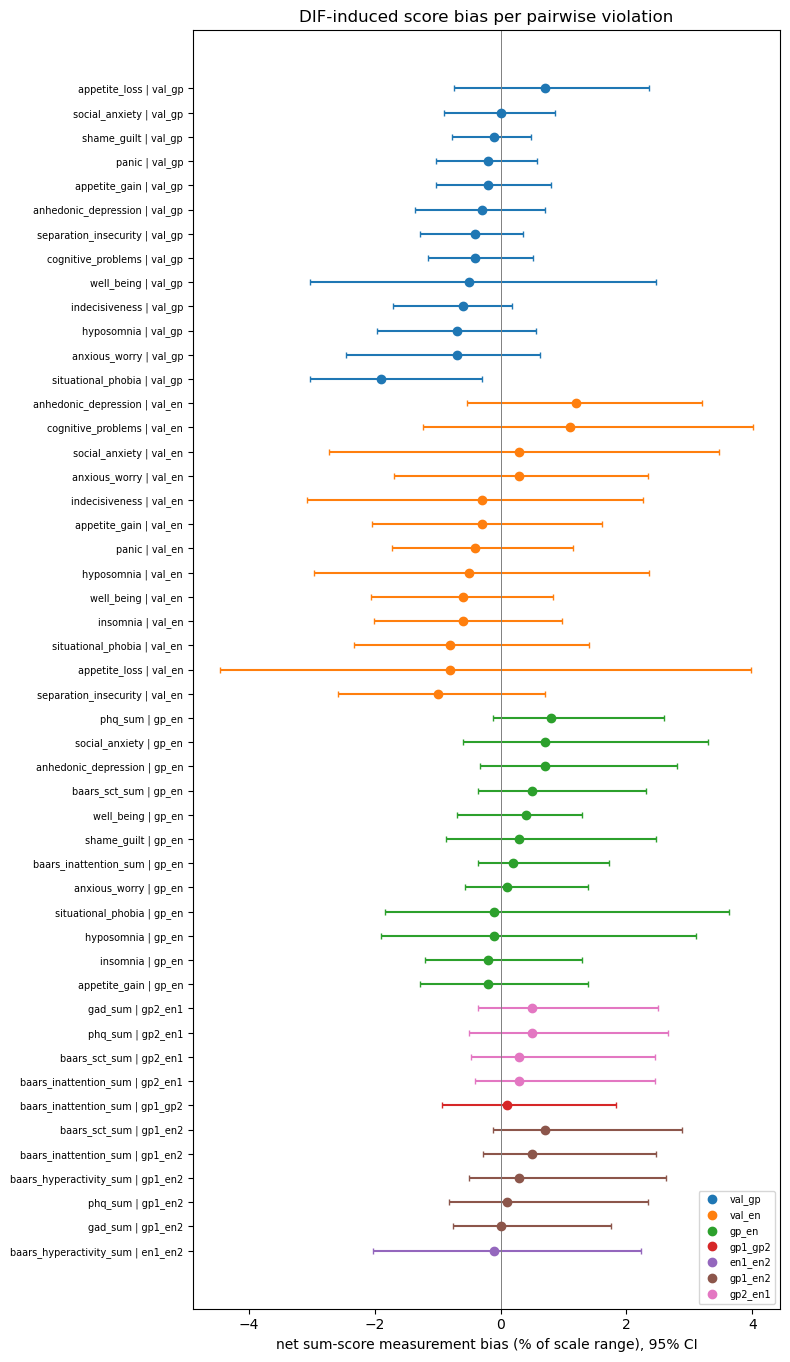

In [7]:
ok = summary[summary.error.isna()].copy()
ok['label'] = ok.scale + ' | ' + ok.pair
ok = ok.sort_values(['pair', 'net_pct'])
pair_colors = {p: c for p, c in zip(PAIR_DATA, plt.cm.tab10.colors)}
fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * len(ok))))
y = np.arange(len(ok))
for j, r in enumerate(ok.itertuples()):
    lo = (r.net_bias_pts - r.net_lo) / r.scale_max * 100
    hi = (r.net_hi - r.net_bias_pts) / r.scale_max * 100
    ax.errorbar(r.net_pct, j, xerr=[[lo], [hi]], fmt='o',
                color=pair_colors[r.pair], capsize=2)
ax.axvline(0, color='gray', lw=0.7)
ax.set_yticks(y); ax.set_yticklabels(ok.label, fontsize=7)
ax.set_xlabel('net sum-score measurement bias (% of scale range), 95% CI')
ax.set_title('DIF-induced score bias per pairwise violation')
handles = [plt.Line2D([], [], marker='o', ls='', color=c, label=p)
           for p, c in pair_colors.items() if p in set(ok.pair)]
ax.legend(handles=handles, fontsize=7, loc='lower right')
fig.tight_layout()

## Reading the table

- **α / real_gap_pts**: the genuine severity difference an invariant instrument would report (latent SD units / expected sum points).
- **net_bias_pts [net_lo, net_hi]**: the sum-score distortion caused by non-uniform DIF, on top of the real gap; `net_pct` scales it by the scale's range for cross-scale comparison. CIs containing zero = no credible *net* score bias despite the invariance failure (item effects cancel).
- **gross_bias_pts**: the sum of |item biases| — the distortion ceiling if items were used separately or reweighted (cancellation not guaranteed off the sum score).
- **max_dMACS / item**: the single worst item (Nye–Drasgow: ~.2 small, ~.4 medium, ~.7 large).
- Rows failing at **configural** carry the extra caveat that the metric model itself approximates.